In [34]:
# ╔════════════════════════════════════════════════════════╗
# ║ Импорт библиотек и загрузка данных (Шаг 1 методички)   ║
# ╚════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Загружаем датасет
df = pd.read_csv("../data/lab4/Bank_Personal_Loan.csv")

# Общий обзор (как в методичке)
print(df.head())
print(df.info())
print(df.describe())


   ID  Age  Experience  Income  ZIP Code  Family CCAvg  Education  Mortgage  \
0   1   25           1      49     91108       4  1/60          1         0   
1   2   45          19      34     90089       3  1/50          1         0   
2   3   39          15      11     94720       1  1/00          1         0   
3   4   35           9     100     94112       1  2/70          2         0   
4   5   35           8      45     91330       4  1/00          2         0   

   Personal Loan  Securities Account  CD Account  Online  CreditCard  
0              0                   1           0       0           0  
1              0                   1           0       0           0  
2              0                   0           0       0           0  
3              0                   0           0       0           0  
4              0                   0           0       0           1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 co

In [35]:
# ╔════════════════════════════════════════════════════════╗
# ║ Удаление ненужных признаков (Шаг 2 методички)          ║
# ╚════════════════════════════════════════════════════════╝

# В методичке удаляли Occupation. Тут удалим ID и ZIP Code.
df.drop(['ID', 'ZIP Code'], axis=1, inplace=True)

# Исправляем ошибочный формат CCAvg (специфично для твоих данных)
df['CCAvg'] = df['CCAvg'].str.replace('/', '.', regex=False).astype(float)


In [37]:
# ╔════════════════════════════════════════════════════════╗
# ║ Проверка и обработка пропусков (Шаг 4 методички)       ║
# ╚════════════════════════════════════════════════════════╝

# В методичке был подробный анализ пропусков. Тут проверим явно:
print("Проверка пропущенных значений:")
print(df.isnull().sum())  # явная проверка на NaN



Проверка пропущенных значений:
Age                   0
Experience            0
Income                0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64


In [39]:
# ╔════════════════════════════════════════════════════════╗
# ║ Нормализация и разбиение данных (Шаг 5 методички)      ║
# ╚════════════════════════════════════════════════════════╝

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X = df.drop('Personal Loan', axis=1)
y = df['Personal Loan']

# Нормализация данных
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Разделение данных на обучение и тест (методичка)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [40]:
# ╔════════════════════════════════════════════════════════╗
# ║ Создание и обучение модели Keras (Шаг 6 методички)     ║
# ╚════════════════════════════════════════════════════════╝

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(X_train, y_train, epochs=25, batch_size=256, validation_split=0.2)



/home/sitavlas/PycharmProjects/MachineLearningLab/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8052 - loss: 0.6229 - val_accuracy: 0.8825 - val_loss: 0.5885
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8822 - loss: 0.5811 - val_accuracy: 0.9025 - val_loss: 0.5491
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8987 - loss: 0.5405 - val_accuracy: 0.9038 - val_loss: 0.5115
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9115 - loss: 0.5002 - val_accuracy: 0.9038 - val_loss: 0.4772
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9084 - loss: 0.4670 - val_accuracy: 0.9038 - val_loss: 0.4470
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9014 - loss: 0.4443 - val_accuracy: 0.9038 - val_loss: 0.4215
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9102 - loss: 0.4086 - val_accuracy: 0.9038 - val_loss: 0.4005
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9078 - loss: 0.3897 - val_accuracy: 0.9038 - val_loss

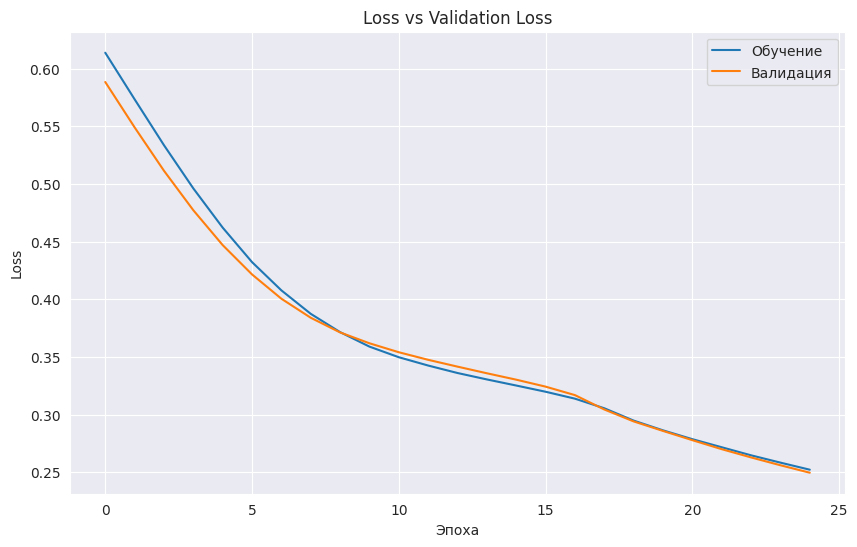

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
                precision    recall  f1-score   support

Не взял кредит       0.91      0.99      0.95       895
   Взял кредит       0.67      0.13      0.22       105

      accuracy                           0.90      1000
     macro avg       0.79      0.56      0.58      1000
  weighted avg       0.88      0.90      0.87      1000



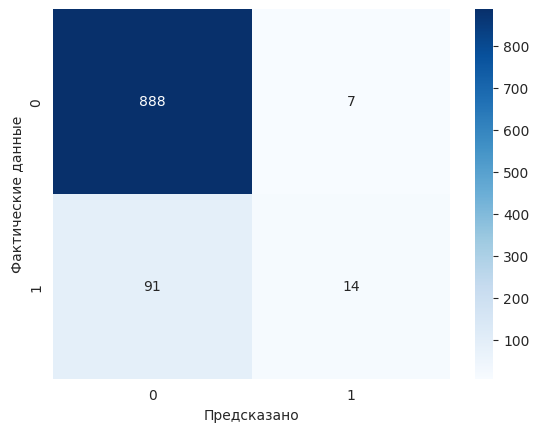

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step


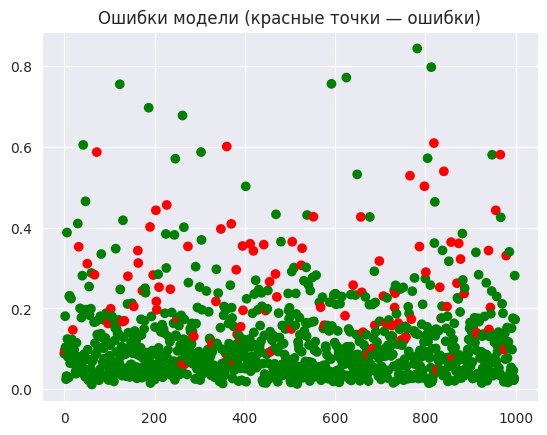

In [41]:
# ╔════════════════════════════════════════════════════════╗
# ║ Оценка производительности (Шаг 7 методички)            ║
# ╚════════════════════════════════════════════════════════╝

# График потерь
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Обучение')
plt.plot(history.history['val_loss'], label='Валидация')
plt.title('Loss vs Validation Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Classification report и confusion matrix
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=['Не взял кредит', 'Взял кредит']))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказано')
plt.ylabel('Фактические данные')
plt.show()

# График анализа ошибок (дополнительно, как твой шаг)
errors = pd.DataFrame({'Факт': y_test, 'Предсказание': y_pred.flatten()})
errors['Ошибка'] = errors['Факт'] != errors['Предсказание']

plt.scatter(range(len(errors)), model.predict(X_test), c=errors['Ошибка'].map({True:'red', False:'green'}))
plt.title("Ошибки модели (красные точки — ошибки)")
plt.show()



In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("📐 Размер X_train:", X_train.shape)
print("📐 Размер X_test:", X_test.shape)


📐 Размер X_train: (4000, 11)
📐 Размер X_test: (1000, 11)


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

# Входной слой + первый скрытый слой
model.add(Dense(units=8, activation='relu', input_shape=(X_train.shape[1],)))

# Второй скрытый слой
model.add(Dense(units=4, activation='relu'))

# Выходной слой
model.add(Dense(units=1, activation='sigmoid'))  # Для бинарной классификации
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Архитектура модели
model.summary()
history = model.fit(X_train, y_train,
                    epochs=25,
                    batch_size=256,
                    validation_split=0.2,
                    verbose=1)


/home/sitavlas/PycharmProjects/MachineLearningLab/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1744541853.705557   13014 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1744541853.706813   13014 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8109 - loss: 0.6861 - val_accuracy: 0.8687 - val_loss: 0.6669
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8689 - loss: 0.6592 - val_accuracy: 0.8988 - val_loss: 0.6217
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9087 - loss: 0.6058 - val_accuracy: 0.9038 - val_loss: 0.5486
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8988 - loss: 0.5371 - val_accuracy: 0.9038 - val_loss: 0.4798
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9112 - loss: 0.4610 - val_accuracy: 0.9038 - val_loss: 0.4321
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9064 - loss: 0.4268 - val_accuracy: 0.9038 - val_loss: 0.4029
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9087 - loss: 0.3941 - val_accuracy: 0.9038 - val_loss: 0.3851
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9056 - loss: 0.3894 - val_accuracy: 0.9038 - val_loss

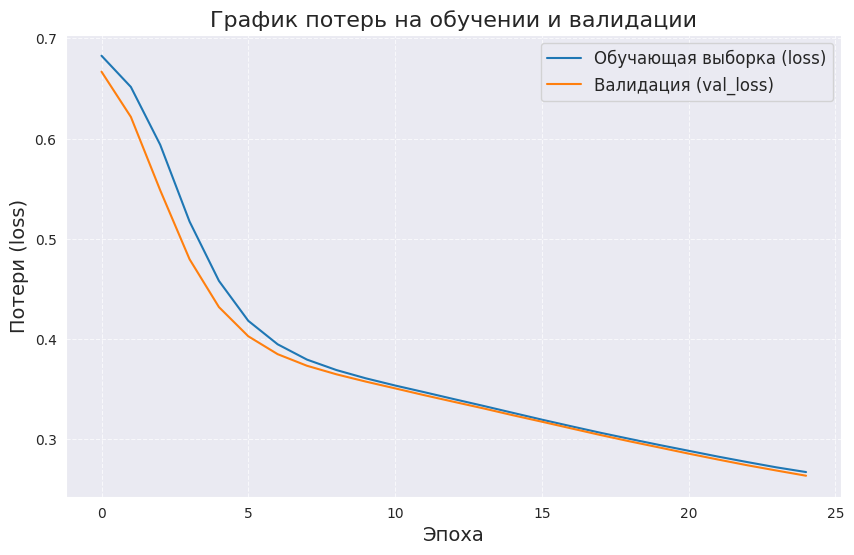

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Обучающая выборка (loss)')
plt.plot(history.history['val_loss'], label='Валидация (val_loss)')
plt.title('График потерь на обучении и валидации', fontsize=16)
plt.xlabel('Эпоха', fontsize=14)
plt.ylabel('Потери (loss)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

📋 Классификационный отчёт:
                    precision    recall  f1-score   support

Не взял кредит (0)       0.90      1.00      0.94       895
   Взял кредит (1)       0.00      0.00      0.00       105

          accuracy                           0.90      1000
         macro avg       0.45      0.50      0.47      1000
      weighted avg       0.80      0.90      0.85      1000



/home/sitavlas/PycharmProjects/MachineLearningLab/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/sitavlas/PycharmProjects/MachineLearningLab/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/sitavlas/PycharmProjects/MachineLearningLab/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control th

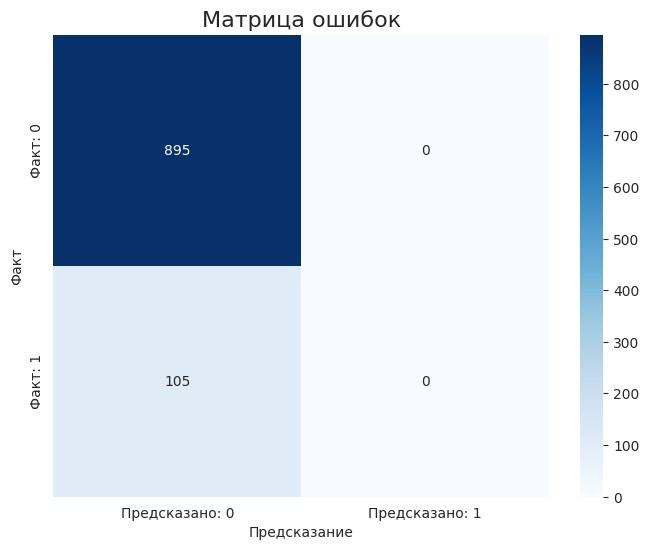

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Предсказания вероятностей
y_pred_prob = model.predict(X_test)

# Переводим в классы (0 или 1)
y_pred = (y_pred_prob > 0.5).astype(int)

# Отчёт о классификации
print("\n📋 Классификационный отчёт:")
print(classification_report(y_test, y_pred, target_names=['Не взял кредит (0)', 'Взял кредит (1)']))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Предсказано: 0', 'Предсказано: 1'],
            yticklabels=['Факт: 0', 'Факт: 1'])
plt.title('Матрица ошибок', fontsize=16)
plt.xlabel('Предсказание')
plt.ylabel('Факт')
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 701us/step


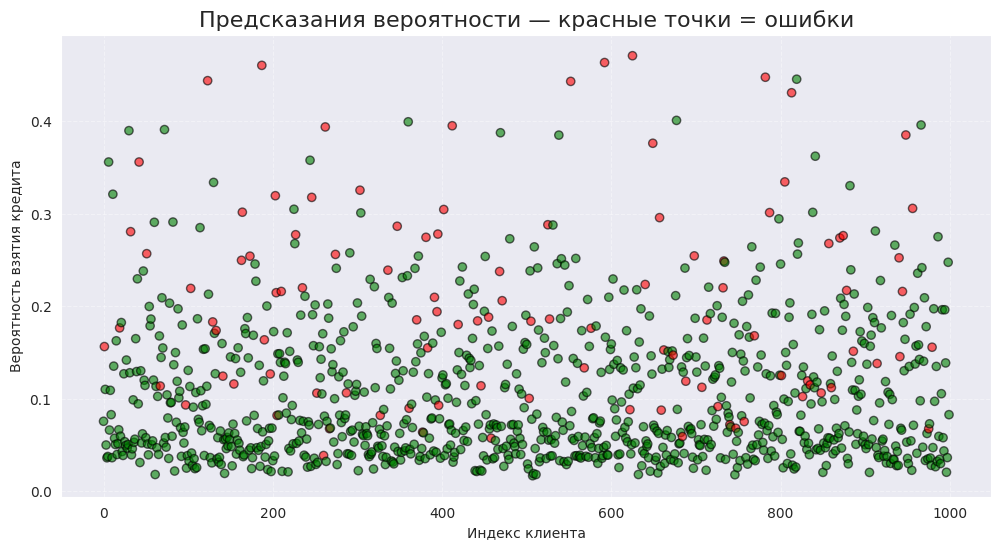

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Предсказания для всех объектов
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Строим DataFrame для сравнения
results = pd.DataFrame({
    'Факт': y_test.values,
    'Предсказание': y_pred.flatten(),
    'Вероятность': y_pred_prob.flatten()
})

# Добавим флаг ошибки
results['Ошибка'] = results['Факт'] != results['Предсказание']

# Построим график распределения вероятностей по классам
plt.figure(figsize=(12, 6))
plt.scatter(x=range(len(results)), y=results['Вероятность'],
            c=results['Ошибка'].map({True: 'red', False: 'green'}),
            alpha=0.6, edgecolors='black')

plt.title("Предсказания вероятности — красные точки = ошибки", fontsize=16)
plt.xlabel("Индекс клиента")
plt.ylabel("Вероятность взятия кредита")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

